# Qwen3.8-Flash-Next NVFP4 on two DGX Spark nodes — SGLang TP=2 notebook

**Measured** receipts: decode 2026-08-26, uncached prefill 2026-08-27 · **quality/cost: untested** · model 176B-total / 6B-active MoE, NVFP4, NEXTN/MTP speculative decoding, TP=2 across two DGX Spark (GB10) nodes over direct RoCE.

Every number in this notebook is transcribed from committed receipts:

- [`results/RESULTS-2026-08-26.md`](../results/2026-08-26-qwen3-8-flash-next-nvfp4-sglang-2node/RESULTS-2026-08-26.md) — decode + functional gates
- [`results/PREFILL-2026-08-27.md`](../results/2026-08-26-qwen3-8-flash-next-nvfp4-sglang-2node/PREFILL-2026-08-27.md) — uncached prefill

both copied from the pinned recipe repository [`PixelML/qwen3-8-flash-next-sglang-2x-dgx-spark @ 682504be`](https://github.com/PixelML/qwen3-8-flash-next-sglang-2x-dgx-spark/tree/682504bec9e7e99206212f4e172b7ec823e4605c). With `LIVE = False` (below) no cell makes a network call. Claims are labeled **measured** (this deployment's receipts) or **untested** (no evidence); cross-model comparisons are directional, not apples-to-apples.

In [1]:
LIVE = False  # Flip only against your own authenticated two-node deployment; committed notebooks stay False.

import pathlib

RECEIPTS = {
    "decode":  "../results/2026-08-26-qwen3-8-flash-next-nvfp4-sglang-2node/RESULTS-2026-08-26.md",
    "prefill": "../results/2026-08-26-qwen3-8-flash-next-nvfp4-sglang-2node/PREFILL-2026-08-27.md",
    "source_repo": "https://github.com/PixelML/qwen3-8-flash-next-sglang-2x-dgx-spark",
    "pinned_revision": "682504bec9e7e99206212f4e172b7ec823e4605c",
}

REPO = pathlib.Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
assert all(pathlib.Path(p).resolve().exists() for k, p in RECEIPTS.items() if k.endswith(("decode", "prefill"))), "receipts missing"

print("LIVE =", LIVE, "— rendering from committed receipts only; no network calls.")

LIVE = False — rendering from committed receipts only; no network calls.


## TL;DR

- **275.4 tok/s aggregate decode at ×16 concurrency** and **47.54 tok/s single-stream**, measured on the verified NEXTN/MTP profile with fixed 192-token coding requests (**measured**, 2026-08-26). A separate 110-token coding response reached 53.86 tok/s.
- **NEXTN/MTP lifts single-stream decode 82%** (26.09 → 47.54 tok/s) and ×16 aggregate **+9.3%** (251.83 → 275.37 tok/s) over the non-speculative baseline; ×4 is 2.6% lower, ×8 3.0% higher. Observed draft acceptance ≈ 0.6–0.8.
- **Uncached prefill: 2,960 input tok/s at a 16K prompt** (median TTFT 5.57 s), 2,759 at 4K, 2,328 at 1K (**measured**, 2026-08-27; unique randomized prefixes, one forced output token, three warm samples per size, zero server-side cache hits across all 50 prefill batches).
- Functional gates passed: text/code generation, `reasoning_content` at low/medium/xhigh effort, structured tool calls, image VQA, authenticated proxy with the public alias; both rank containers stayed healthy with **zero restarts**.
- **Untested:** scored quality/accuracy, energy and cost-per-task, single-node serving, other prompt shapes and quantizations.

In [2]:
# Decode receipts — results/RESULTS-2026-08-26.md (measured 2026-08-26)
# Aggregate output tok/s = completion tokens from the API usage count / wall-clock seconds.
# Workload: identical 192-token coding requests submitted directly to rank zero, TP=2 over two DGX Spark nodes.

CONCURRENCY   = [1, 4, 8, 16]
TOK_MTP       = [192, 750, 1536, 3072]   # completion tokens (usage object)
WALL_MTP_S    = [4.038, 8.567, 9.711, 11.156]
TPS_MTP       = [47.54, 87.55, 158.17, 275.37]   # verified NEXTN/MTP profile
TPS_BASELINE  = [26.09, 89.93, 153.54, 251.83]   # non-speculative baseline (x1 has no token/wall detail in the receipt)
TPS_LIVELOAD  = [25.49, 95.17, 133.38, 195.63]   # recheck while rank zero also downloaded a checkpoint at low priority

SINGLE_EXTRAS = {  # tok/s, one-off samples from the same receipt
    "single 110-token coding response (MTP)": 53.86,
    "single request via authenticated TLS proxy, pre-MTP (incl. proxy/TLS/network latency)": 21.77,
}

hdr = f"{'conc':>5} | {'MTP tok':>8} {'wall s':>7} | {'MTP':>7} {'baseline':>8} {'live-load':>9} | {'MTP vs base':>11}"
print(hdr); print("-" * len(hdr))
for i, c in enumerate(CONCURRENCY):
    delta = (TPS_MTP[i] - TPS_BASELINE[i]) / TPS_BASELINE[i] * 100
    print(f"{c:>5} | {TOK_MTP[i]:>8} {WALL_MTP_S[i]:>7.3f} | {TPS_MTP[i]:>7.2f} {TPS_BASELINE[i]:>8.2f} {TPS_LIVELOAD[i]:>9.2f} | {delta:>+10.1f}%")

print()
for label, tps in SINGLE_EXTRAS.items():
    print(f"{tps:>6.2f} tok/s  — {label}")

 conc |  MTP tok  wall s |     MTP baseline live-load | MTP vs base
-------------------------------------------------------------------
    1 |      192   4.038 |   47.54    26.09     25.49 |      +82.2%
    4 |      750   8.567 |   87.55    89.93     95.17 |       -2.6%
    8 |     1536   9.711 |  158.17   153.54    133.38 |       +3.0%
   16 |     3072  11.156 |  275.37   251.83    195.63 |       +9.3%

 53.86 tok/s  — single 110-token coding response (MTP)
 21.77 tok/s  — single request via authenticated TLS proxy, pre-MTP (incl. proxy/TLS/network latency)


## Visible results

Decode aggregate throughput by concurrency for the three receipt runs, and the uncached-prefill sweep. The chart is written to `assets/charts/` as PNG + SVG alongside this notebook's repository.

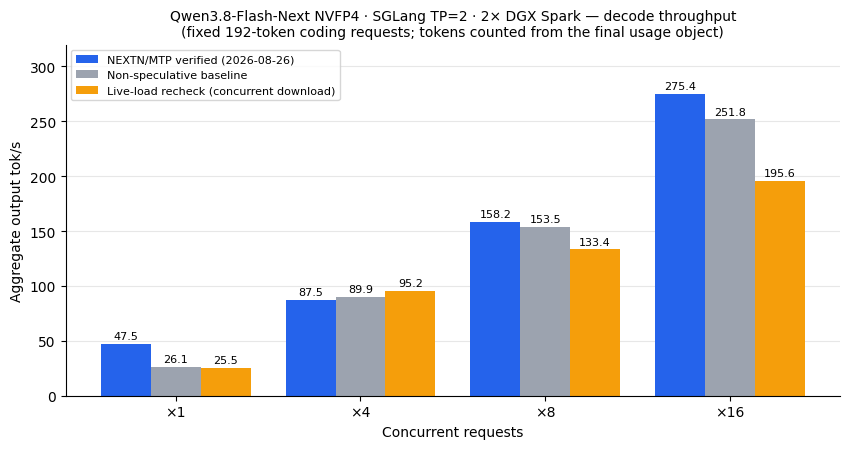

wrote /tmp/wt-dgx-qwen38/assets/charts/qwen3-8-flash-next-nvfp4-2node-sglang-decode.png
wrote /tmp/wt-dgx-qwen38/assets/charts/qwen3-8-flash-next-nvfp4-2node-sglang-decode.svg


In [3]:
import matplotlib.pyplot as plt
import numpy as np

CHART_DIR = REPO / "assets" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

x = np.arange(len(CONCURRENCY)); w = 0.27
fig, ax = plt.subplots(figsize=(8.6, 4.6))
b1 = ax.bar(x - w, TPS_MTP,      w, label="NEXTN/MTP verified (2026-08-26)", color="#2563eb")
b2 = ax.bar(x,     TPS_BASELINE, w, label="Non-speculative baseline",        color="#9ca3af")
b3 = ax.bar(x + w, TPS_LIVELOAD, w, label="Live-load recheck (concurrent download)", color="#f59e0b")

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)

ax.set_xticks(x); ax.set_xticklabels([f"×{c}" for c in CONCURRENCY])
ax.set_xlabel("Concurrent requests")
ax.set_ylabel("Aggregate output tok/s")
ax.set_title("Qwen3.8-Flash-Next NVFP4 · SGLang TP=2 · 2× DGX Spark — decode throughput\n(fixed 192-token coding requests; tokens counted from the final usage object)", fontsize=10)
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.set_ylim(0, 320)
fig.tight_layout()

png = CHART_DIR / "qwen3-8-flash-next-nvfp4-2node-sglang-decode.png"
svg = CHART_DIR / "qwen3-8-flash-next-nvfp4-2node-sglang-decode.svg"
fig.savefig(png, dpi=150); fig.savefig(svg)
plt.show()
print("wrote", png); print("wrote", svg)

In [4]:
# Uncached prefill receipts — results/PREFILL-2026-08-27.md (measured 2026-08-27)
# Client-observed: unique randomized prefix per request, temperature 0, streaming, exactly one
# requested output token; input tok/s = API prompt_tokens / time to first content-or-reasoning
# token (includes HTTP, tokenization, scheduling, first decode). Medians of three warm samples.

PREFILL = [
    # target, median actual prompt tok, median TTFT s, median input tok/s, three-run range tok/s
    ("1K",  1_046, 0.4524, 2_327.78, "2,281.64–2,384.69"),
    ("4K",  4_103, 1.4924, 2_758.65, "2,622.26–2,959.58"),
    ("16K", 16_471, 5.5729, 2_960.12, "2,940.77–2,960.96"),
]

hdr = f"{'prompt':>6} | {'median prompt tok':>17} | {'median TTFT':>11} | {'median input tok/s':>18} | {'three-run range':>20}"
print(hdr); print("-" * len(hdr))
for tgt, ptok, ttft, tps, rng in PREFILL:
    print(f"{tgt:>6} | {ptok:>17,} | {ttft:>9.4f}s | {tps:>18,.2f} | {rng:>20}")
print()
print("Server-side '#cached-token: 0' on all 50 prefill batches in the final run window (per receipt).")

prompt | median prompt tok | median TTFT | median input tok/s |      three-run range
------------------------------------------------------------------------------------
    1K |             1,046 |    0.4524s |           2,327.78 |    2,281.64–2,384.69
    4K |             4,103 |    1.4924s |           2,758.65 |    2,622.26–2,959.58
   16K |            16,471 |    5.5729s |           2,960.12 |    2,940.77–2,960.96

Server-side '#cached-token: 0' on all 50 prefill batches in the final run window (per receipt).


## Reproduce

Full recipe and pinned artifacts live in the model repository:
[`PixelML/qwen3-8-flash-next-sglang-2x-dgx-spark @ 682504be`](https://github.com/PixelML/qwen3-8-flash-next-sglang-2x-dgx-spark/tree/682504bec9e7e99206212f4e172b7ec823e4605c)
(adapted from the [official SGLang cookbook](https://docs.sglang.io/cookbook/autoregressive/Qwen/Qwen3.8-Flash-Next)). Checkpoint:
[`PixelML/Qwen3.8-Flash-Next-NVFP4-Dual-DGX-Spark`](https://huggingface.co/PixelML/Qwen3.8-Flash-Next-NVFP4-Dual-DGX-Spark) @ `b80180e371f13348ec49641a6e66999e7854b179`,
an attributed exact mirror of `RadixArk/Qwen3.8-Flash-Next-NVFP4` @ `7b719225242aacd3dbd3f9407468c2ee9a9d2594`.

Prerequisites: two DGX Spark nodes on the same NVIDIA system-software release, a direct Ethernet/RoCE link between them, the same Linux username/UID/GID on both nodes, Docker configured for the non-root deployment user, SSH aliases from the controller to both nodes, and ≥160 GB free storage per node.

1. Clone the recipe repository to the same path on both Spark nodes and the controller.
2. `cp .env.example .env`, then set the node host aliases, the model directory (same path on both nodes), the **rank-zero address on the direct RoCE subnet**, the distribution port, and interface/HCA settings for your cluster; copy `.env` to both nodes.
3. `./scripts/prepare-model.sh` on each Spark — downloads and verifies the pinned checkpoint revision.
4. Generate one API secret on the controller (`umask 077; openssl rand -hex 32 > .sglang-api-key`) and copy the same file to both nodes. Never commit it.
5. `./scripts/start-cluster.sh` from the controller (starts rank 1 before rank 0). Rank zero serves an OpenAI-compatible API on port 8888; keep it on the private network or behind an authenticated TLS proxy.
6. Validate and measure:

   ```bash
   ssh <rank-1-alias> 'cd <deploy-dir> && python3 scripts/smoke-benchmark.py'
   python3 scripts/prefill-benchmark.py   # unique-prefix uncached TTFT/prefill; fresh seed per invocation
   ```

7. Decode benchmark shape (receipt methodology): identical 192-token coding requests straight at rank zero, aggregate output tok/s = completion tokens from the final usage object ÷ wall time. Count tokens from the usage object, never from stream-event counts.

Applying the SM121 compatibility patch (`scripts/apply-sm121-qsa-patch.sh`) is part of the launch path on the pinned day-zero SGLang image — see the Appendix for why it exists.

## Appendix

### Configuration pins (measured profile)

| Pin | Value |
|---|---|
| Model | `PixelML/Qwen3.8-Flash-Next-NVFP4-Dual-DGX-Spark` @ `b80180e371f13348ec49641a6e66999e7854b179` (mirror integrity: 418 non-card upstream files matched against `RadixArk/Qwen3.8-Flash-Next-NVFP4` @ `7b719225242aacd3dbd3f9407468c2ee9a9d2594`) |
| Source model | `Qwen/Qwen3.8-Flash-Next` @ `f5d08274bafd880402bd16f5e3e6c514136ec06c` |
| Scale | 176B total parameters, 6B active per token |
| Runtime | SGLang `0.0.0.dev1+gd91c3682b`, image `lmsysorg/sglang@sha256:12d3392bdc8be8d35e9a95f191df6aef99c5114bdbefd41bfdc7e760e6d25ec1` |
| Hardware / topology | 2× DGX Spark, one GB10 (SM121) GPU per node, TP=2, direct RoCE link |
| Quantization | ModelOpt NVFP4 W4A4 — routed experts only, in the 48 main-model MoE layers; attention, QSA, GDN, mHC, shared experts, routers, embeddings, LM head, vision, and MTP tensors stay BF16; PLE n-gram tables FP8 weights; FlashInfer CUTLASS GEMM/MoE |
| Calibration | 128 `cnn_dailymail` articles plus representativeness probing (per upstream RadixArk card) |
| Context | 262,144 tokens; 4,096-token chunked prefill; `MEM_FRACTION_STATIC=0.80` |
| Request limit | configured `MAX_RUNNING_REQUESTS=36` → **effective 25** with MTP (extra Mamba state per request) |
| Speculative decoding | NEXTN/MTP: 3 steps, top-k 1, 4 draft tokens; ≈1.45–1.49 GB draft weights per rank; acceptance ≈ 0.6–0.8 |
| License | Qwen Community License 1.0 (weights); MIT (recipe code) |

### Why the SM121 patch exists (measured failure modes)

- **Startup failure:** on SM121 the pinned image falls back to a FlashAttention-4 CuTe QSA decode path that fails to compile ("weakly congruent" view coordinates/shapes). The patched backend uses FlashInfer XQA on SM120/SM121 instead.
- **Silent corruption:** FlashInfer's TRT-LLM sparse-decode kernel emits token id 0 (`!`) at long context on SM121 (upstream sglang#36806, sglang#36537). The ported fix (sglang#36845, from MiaAI-Lab's DSpark work, commit `0f95001`) swaps in a Triton packed-varlen fallback and adds a token-0 guard: 16 consecutive token-id-0 samples abort the request with HTTP 500 / `finish_reason=abort`, skip radix-tree insertion, and reset the prefix cache before the next prefill.
- **Linear-attention state dtype:** Gated DeltaNet runs Triton for prefill and FlashInfer for decode with BF16 Mamba state; using FlashInfer for both phases trips state-dtype incompatibilities on SM121.

### Methodology and caveats

- Aggregate decode tok/s = completion tokens (final API usage object) ÷ wall-clock time; single fixed 192-token prompt shape, direct to rank zero. The live-load recheck ran while rank zero was also downloading a large checkpoint at low priority — treat it as the busy-node range, not the headline.
- The pre-MTP proxy sample (21.77 tok/s) includes TLS/proxy/network latency and is not server capacity.
- Uncached prefill: one request at a time, unique randomized prefix, one forced output token, three calibrated warm samples per size, medians and full ranges reported; end-to-end TTFT is used deliberately because SGLang's per-chunk log field can spike on small tail chunks. Prefill rates are client-observed and not comparable to aggregate decode TPS.
- MTP trade-offs: ×4 aggregate 2.6% lower than baseline in the verified run; effective request limit drops 36 → 25.

### Receipt gaps (do not fill from memory)

- No power draw, temperature, memory utilization, or thermal telemetry in the receipts.
- No scored quality/accuracy evaluation — functional gates only; quality and cost-per-task **untested**.
- Non-speculative ×1 row has no completion-token/wall-time detail in the receipt (aggregate only).
- Decode: one prompt shape, one run per concurrency point (no stated medians/ranges); prefill: n=3 per size.
- No single-node run, no other quantizations/runtimes, no energy or cost data.

### Provenance

- Receipts (this repo): [`results/2026-08-26-qwen3-8-flash-next-nvfp4-sglang-2node/`](../results/2026-08-26-qwen3-8-flash-next-nvfp4-sglang-2node/)
- Recipe repo (pinned): [`qwen3-8-flash-next-sglang-2x-dgx-spark @ 682504be`](https://github.com/PixelML/qwen3-8-flash-next-sglang-2x-dgx-spark/tree/682504bec9e7e99206212f4e172b7ec823e4605c)
- Club summary: [`results/SUMMARY.md`](../results/SUMMARY.md) · method: [`docs/BENCHMARK-METHOD.md`](../docs/BENCHMARK-METHOD.md)
- Hugging Face mirror card: [`PixelML/Qwen3.8-Flash-Next-NVFP4-Dual-DGX-Spark`](https://huggingface.co/PixelML/Qwen3.8-Flash-Next-NVFP4-Dual-DGX-Spark)

In [5]:
import os
chart_png = CHART_DIR / "qwen3-8-flash-next-nvfp4-2node-sglang-decode.png"
chart_svg = CHART_DIR / "qwen3-8-flash-next-nvfp4-2node-sglang-decode.svg"
assert LIVE is False, "Committed notebooks must ship with LIVE = False."
assert chart_png.exists() and chart_svg.exists(), "chart artifacts missing"

print("Notebook state")
print("  LIVE:                False (receipt-backed; no network calls made)")
print("  receipts referenced:", RECEIPTS["decode"].split("/")[-1] + ",", RECEIPTS["prefill"].split("/")[-1])
print("  chart artifacts:     " + chart_png.name + ",", chart_svg.name)
print("  headline (measured): 47.54 tok/s x1 / 275.37 tok/s x16 aggregate decode; 2,960.12 input tok/s @ 16K uncached prefill")

Notebook state
  LIVE:                False (receipt-backed; no network calls made)
  receipts referenced: RESULTS-2026-08-26.md, PREFILL-2026-08-27.md
  chart artifacts:     qwen3-8-flash-next-nvfp4-2node-sglang-decode.png, qwen3-8-flash-next-nvfp4-2node-sglang-decode.svg
  headline (measured): 47.54 tok/s x1 / 275.37 tok/s x16 aggregate decode; 2,960.12 input tok/s @ 16K uncached prefill
